In [1]:
import numpy as np
import matplotlib.pyplot as plt
from deepOnet_definitions import *
from FFEM_building_blocks import Mesh


# automatic generation of source functions and the Poisson solution algorithm

def generate_source_function(num_modes:int=3, max_freq:int=4, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

In [3]:
x_branch = np.linspace(-1, 1, 20)
y_branch = np.linspace(-1, 1, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)


don = deepOnet_v1(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)


don.fit_from_npz('data/dataset.npz', 14000)

Y std across samples: 0.04507255181670189
Y std across points: 0.036380499601364136
Epoch [100/14000], Loss: 0.0034, Loss eval: 0.0033
prediction std across samples: 0.041891910135746
prediction std across points: 0.023514775559306145
Epoch [200/14000], Loss: 0.0024, Loss eval: 0.0023
prediction std across samples: 0.03939707204699516
prediction std across points: 0.004836908541619778
Epoch [300/14000], Loss: 0.0023, Loss eval: 0.0022
prediction std across samples: 0.038405049592256546
prediction std across points: 0.004711249377578497
Epoch [400/14000], Loss: 0.0022, Loss eval: 0.0021
prediction std across samples: 0.03763250261545181
prediction std across points: 0.004584812093526125
Epoch [500/14000], Loss: 0.0021, Loss eval: 0.0021
prediction std across samples: 0.03703490272164345
prediction std across points: 0.00446360232308507
Epoch [600/14000], Loss: 0.0021, Loss eval: 0.0020
prediction std across samples: 0.03657127916812897
prediction std across points: 0.004350516013801098


KeyboardInterrupt: 

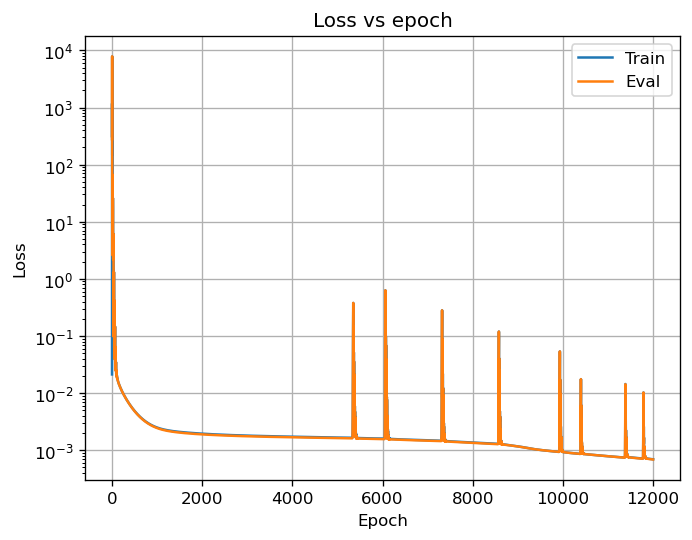

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_61156/247360811.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


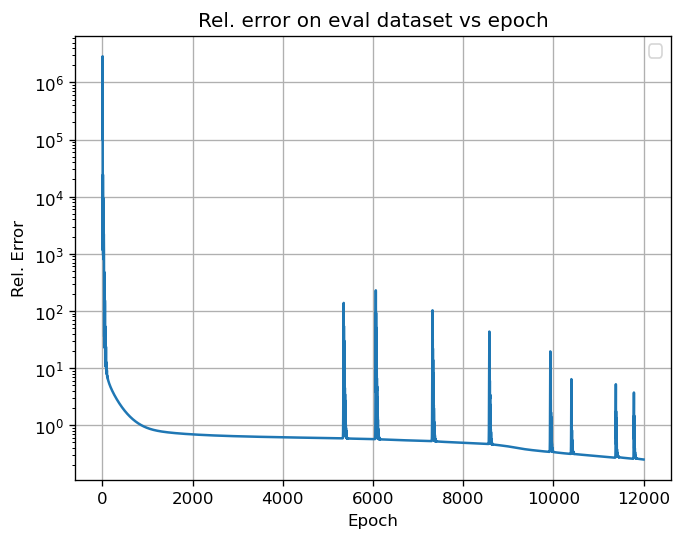

In [ ]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don.epochs, don.losses, label = "Train")
plt.semilogy(don.epochs, don.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don.epochs, don.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


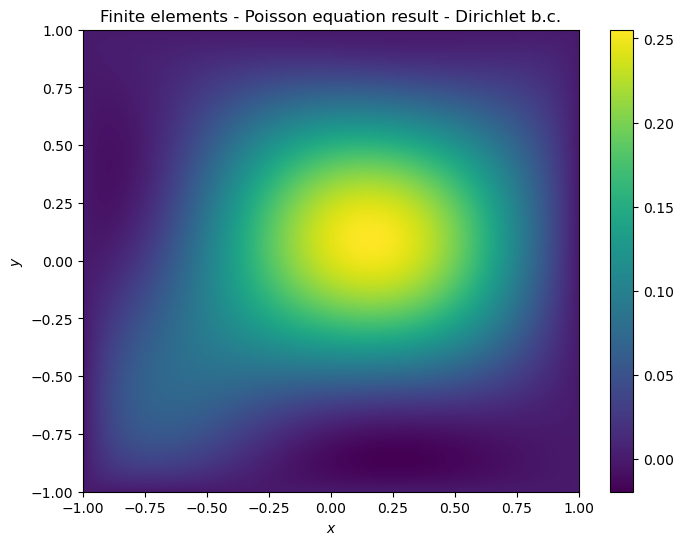

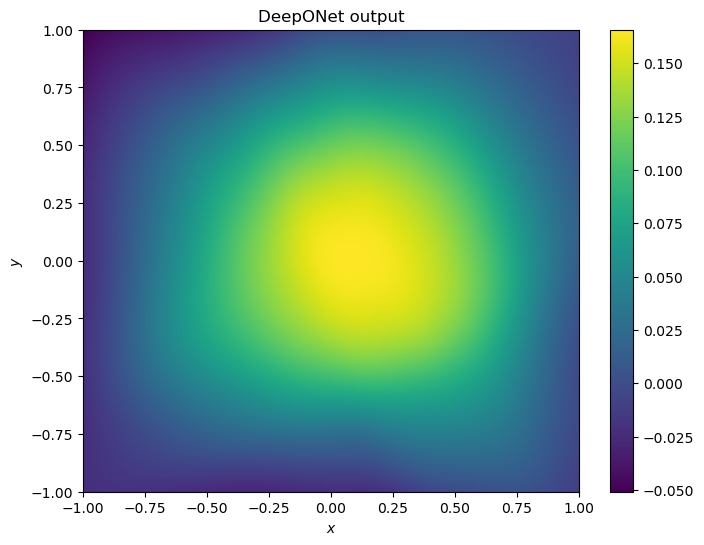

In [ ]:
# now test visually on a randomly generated function

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


result_don = don.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('DeepONet output')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

In [ ]:
# TO DO: more quantitative tests on a control dataset

# TO DO: try GRF for lower effective dimensionality

**The code now runs, but the results are not that good**
In particular; the relative error on the eval dataset plateaus to 1. this is due to the fact that the output is basically identical for all points in the domain. Issue with the trunk sector?

more work needs to be done since from the plots above one can clearly see that the results do not match. Reduce dimensionaly ? (GRF)


"explodes" after around 15000 epochs

**Now try Fourier encoding**

based on https://arxiv.org/pdf/2509.12344.

Y std across samples: 0.04507255181670189
Y std across points: 0.036380499601364136
Epoch [100/15000], Loss: 0.0227, Loss eval: 0.0204
prediction std across samples: 0.10828670859336853
prediction std across points: 0.054163023829460144
Epoch [200/15000], Loss: 0.0066, Loss eval: 0.0065
prediction std across samples: 0.055235691368579865
prediction std across points: 0.0393788106739521
Epoch [300/15000], Loss: 0.0050, Loss eval: 0.0049
prediction std across samples: 0.05410856381058693
prediction std across points: 0.03162732347846031
Epoch [400/15000], Loss: 0.0044, Loss eval: 0.0044
prediction std across samples: 0.05344920605421066
prediction std across points: 0.027788886800408363
Epoch [500/15000], Loss: 0.0041, Loss eval: 0.0041
prediction std across samples: 0.051927655935287476
prediction std across points: 0.02560294046998024
Epoch [600/15000], Loss: 0.0039, Loss eval: 0.0038
prediction std across samples: 0.05049712955951691
prediction std across points: 0.02393927052617073
E

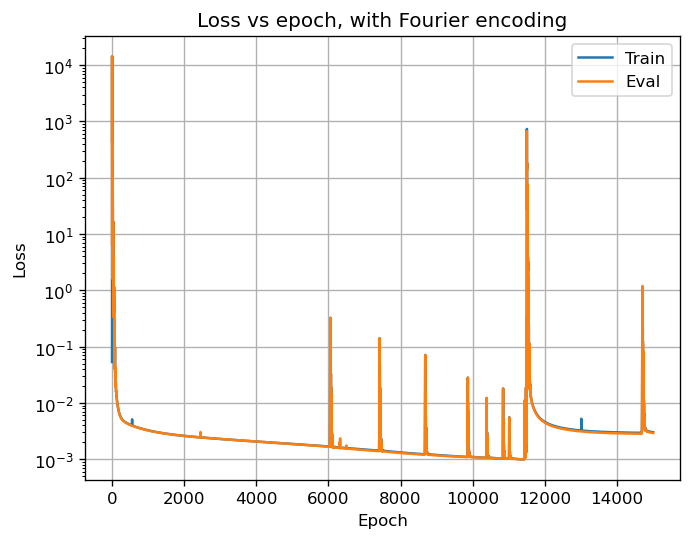

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_1882/3104024548.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


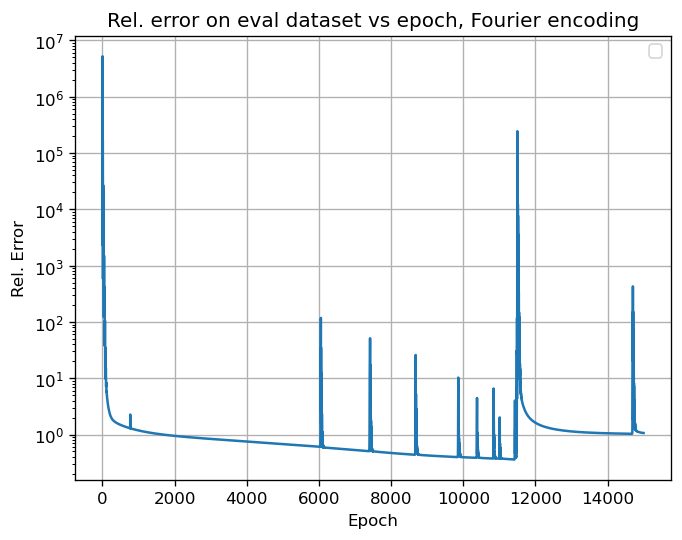

In [6]:
# Now try Fourier encoding

x_branch = np.linspace(-1, 1, 20)
y_branch = np.linspace(-1, 1, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)

don_fourier = deepOnet_fourier_embedded_v2(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)

don_fourier.fit_from_npz('data/dataset.npz', 15000)

plt.figure(dpi = 120)
plt.title("Loss vs epoch, with Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don_fourier.epochs, don_fourier.losses, label = "Train")
plt.semilogy(don_fourier.epochs, don_fourier.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch, Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don_fourier.epochs, don_fourier.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


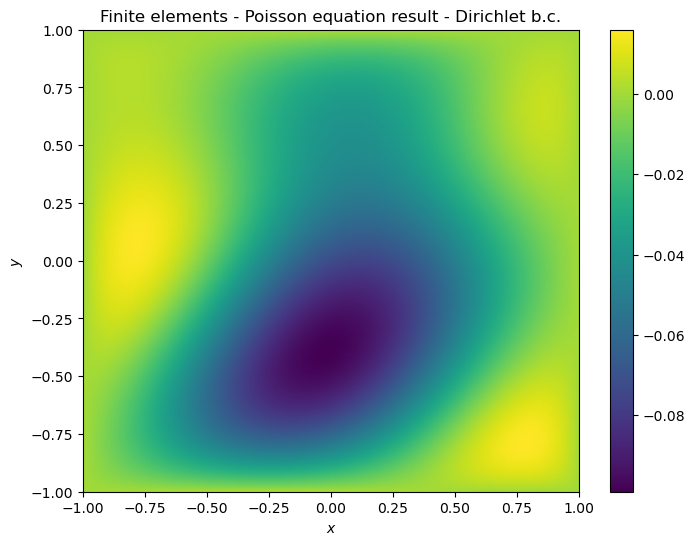

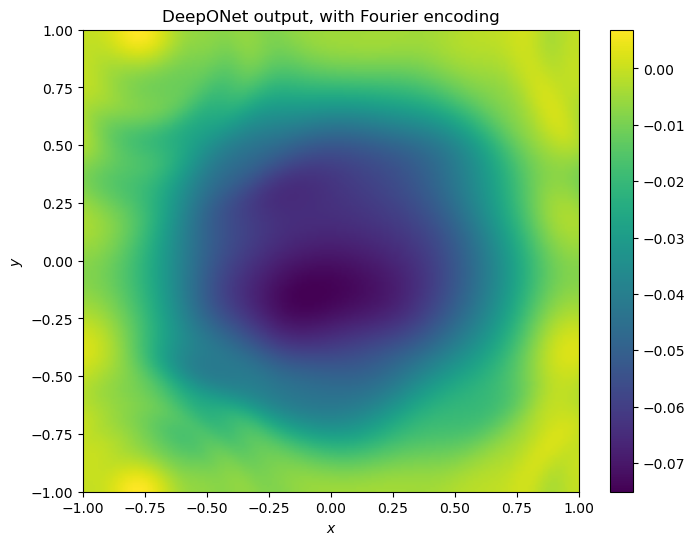

In [ ]:
# now test visually on a randomly generated function

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

result_don_fourier = don_fourier.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().cpu().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don_fourier, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('DeepONet output, with Fourier encoding')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

# plot shown here obtained with 10000 iterations

In [ ]:
# in any case the frequency encoding should not play a big role since the functions I am using (so far!) in the training dataset have quite low frequency 
# (at least that is my intuition)
# on the other hand, if one wanted one could add more frequencies to the encoding, i.e. sin(k * 2pi x)


# independently from the frequency encoding I should probably work on the training parameters. the convergence process is quite slow, can "explode" after >1500 iterations. 
# I should probably fix this first, since with many iterations the model's output seem to get, at least qualitatively, closer to the desired solution
